<a href="https://colab.research.google.com/github/AndronIxI/cpp/blob/main/%D0%9C%D0%B5%D0%92%D0%94_2_%D0%BB%D0%B0%D0%B1%D0%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Постановка задачи


**Цель работы:** изучение основных способов визуализации табличных данных с помощью модулей `seaborn`, `plotly`, `altair`, `bokeh`.

**Краткое описание:** в лабораторной работе представлено 10 заданий на построение графиков разных видов. В каждом задании указано, каким видом графика стоит воспользоваться для визуализации данных. По каждому заданию необходимо построить график дважды: первый раз с помощью модуля `seaborn` (альтернативно можно `matplotlib` со стилями из `seaborn`), второй – с помощью `plotly`, `altair` или `bokeh` на выбор студента. Необязательно каждый раз для второго графика выбирать одну и ту же библиотеку, т.к. не все библиотеки располагают одинаковым набором графиков.

# Данные


По [ссылке](https://drive.google.com/drive/folders/1e0E4vQzaE9LBZgfzz0AzsyAXgtH0eMaP?usp=share_link) расположена таблица с информацией о песнях, исполненных на Евровидении с 2009 по 2023 год. Все задания лабораторной работы необходимо выполнять по этим данным. Данные в полном объеме можно найти [по ссылке](https://www.kaggle.com/datasets/diamondsnake/eurovision-song-contest-data).

##### **Формат данных**

```
year,country,artist_name,song_name,language,style,gender,main_singers,key,BPM,energy,danceability,happiness,loudness,acousticness,instrumentalness,liveness,speechiness,final_place
2023,Norway,Alessandra,Queen of Kings,English,Pop,Female,1,E Minor,110,36,64,23,10 dB,58,0,10,3,5
2023,Malta,The Busker,Dance (Our Own Party),English,Pop,Male,1,F Minor,103,78,70,82,6 dB,2,0,18,4,
...
```
##### **Описание полей**

- ```year``` – год;
- ```country``` – страна участника;
- ```artist_name``` – исполнитель;
- ```song_name``` – название песни;
- ```language``` – язык, на котором исполняется песня;
- ```style```	– жанр;
- ```gender``` – пол участника;
- ```main_singers``` – количество вокалистов;
- ```key```	– регистр (высота тона);
- ```BPM``` – скорость композиции в целом (количество четвертых нот в минуту);
- ```energy``` – энергичность композиции;
- ```danceability``` – танцевальность (насколько трек подходит для танцев);
- ```happiness``` – жизнерадостность;
- ```loudness``` – громкость;
- ```acousticness``` – акустичность;
- ```instrumentalness``` – инструментальность;
- ```liveness``` – живость;
- ```speechiness``` – насколько много текста;
- ```final_place``` – место в фонале.

# Практические задания

>По каждому заданию должен быть сделан вывод. Также нужно обязательно добавлять подпись графика и осей.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import altair as alt
import seaborn as sns
import re
from IPython.display import display

In [3]:
df = pd.read_csv("/content/song_data (1).csv")

## Задание 1

Проведите предобработку числовых значений в датасете:
1. В столбцах `BPM`, `energy`, `danceability`, `happiness`, `acousticness`, `instrumentalness`, `liveness`, `speechiness` замените отсутствующие значения и прочерки на 0.
2. В столбце `loudness` оставьте только число без единиц измерения.
3. Во всех перечисленных в пунктах 1 и 2 столбцах преобразуйте значения в тип данных `float`.

In [4]:
task = ['BPM', 'energy', 'danceability', 'happiness', 'acousticness', 'instrumentalness', 'liveness', 'speechiness']
df[task] = df[task].astype(str).applymap(str.strip).replace('-', 0).fillna(0)

df['loudness'] = df['loudness'].astype(str).str.extract(r'(-?\d+)')[0]

df[task + ['loudness']] = df[task + ['loudness']].astype(float)

df

<ipython-input-4-5ee0667f8d33>:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[task] = df[task].astype(str).applymap(str.strip).replace('-', 0).fillna(0)


,year,country,artist_name,song_name,language,style,gender,main_singers,key,BPM,energy,danceability,happiness,loudness,acousticness,instrumentalness,liveness,speechiness,final_place
0,2023,Norway,Alessandra,Queen of Kings,English,Pop,Female,1,E Minor,110.0,36.0,64.0,23.0,10.0,58.0,0.0,10.0,3.0,5.0
1,2023,Malta,The Busker,Dance (Our Own Party),English,Pop,Male,1,F Minor,103.0,78.0,70.0,82.0,6.0,2.0,0.0,18.0,4.0,NaN
2,2023,Serbia,Luke Black,Samo mi se spava,"Serbian, English",Pop,Male,1,A Major,103.0,70.0,56.0,11.0,10.0,4.0,2.0,32.0,5.0,24.0
3,2023,Latvia,Sudden Lights,Aija,English,Rock,Male,1,A Minor,160.0,55.0,56.0,40.0,8.0,5.0,0.0,8.0,7.0,NaN
4,2023,Portugal,Mimicat,Ai coraçăo,Portuguese,Pop,Female,1,Fs Minor,145.0,63.0,66.0,77.0,8.0,31.0,0.0,16.0,5.0,23.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
560,2009,France,Patricia Kaas,Et s'il fallait le faire,French,Ballad,Female,1,A Major,92.0,58.0,26.0,23.0,8.0,55.0,0.0,90.0,8.0,8.0
561,2009,Russia,Anastasiya Prikhodko,Mamo,"Russian, Ukrainian",Ballad,Female,1,D Minor,130.0,94.0,64.0,45.0,4.0,41.0,0.0,26.0,5.0,11.0
562,2009,Germany,Alex Swings Oscar Sings!,Miss Kiss Kiss Bang,English,Pop,Male,1,Bb Minor,136.0,89.0,62.0,56.0,4.0,11.0,0.0,20.0,21.0,20.0
563,2009,United Kingdom,Jade Ewen,It's My Time,English,Ballad,Female,1,E Major,105.0,31.0,30.0,12.0,14.0,1.0,79.0,29.0,3.0,5.0


# Вывод
Данные оказались уже хорошо обработаны, и как мне показалось, в том же столбце loudness все данные были строго одного формата '\d+ dB'. В общем проблем не возникло

## Задание 2

Покажите, какие характеристики музыки (`BPM`, `energy`, `danceability`, `happiness`, `acousticness`, `instrumentalness`, `liveness`, `speechiness`) коррелируют между собой. Для визуализации используйте диаграмму `heatmap`.

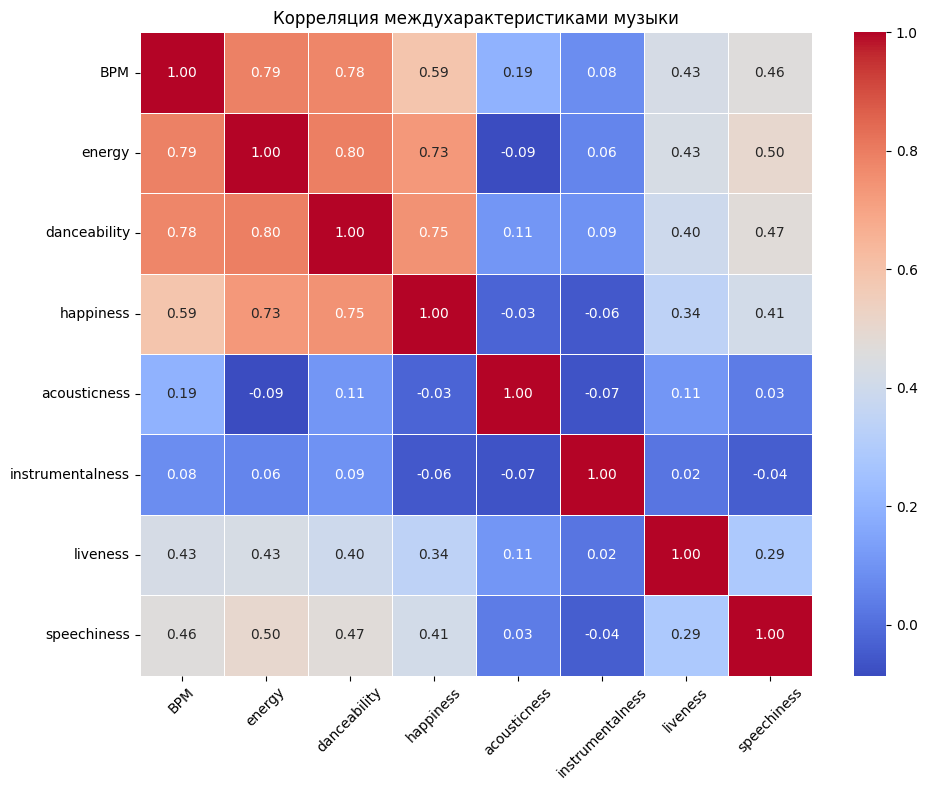

In [17]:
task = ['BPM', 'energy', 'danceability', 'happiness', 'acousticness', 'instrumentalness', 'liveness', 'speechiness']

corr_matrix = df[task].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Корреляция междухарактеристиками музыки')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.grid(False)
plt.show()



fig = px.imshow(
    corr_matrix,
    text_auto=".2f",
    color_continuous_scale="RdBu_r",
    aspect="auto",
    title="Корреляция между характеристиками музыки (Plotly)"
)

fig.update_layout(
    width=900,
    height=900,
    xaxis_title="",
    yaxis_title=""
)
fig.update_xaxes(side="bottom")
fig.show()

# Вывод
Преимущественно данные либо связаны, но лишь на половину, либо они вообще почти не связаны. Таких случаев, чтобы данные были связаны обратно пропорционально - отсутствуют. К примеру bpm и energy достаточно тесно связаны, а instrumentalness и happines почти нет

## Задание 3

Покажите на диаграмме разброса взаимосвязь между жизнерадостностью (`happiness`) и энергичностью (`energy`) композиции. Добавьте на диаграмму вспомогательные элементы (отметку средних значений, выбросов) для упрощения интерпретации визуализации.



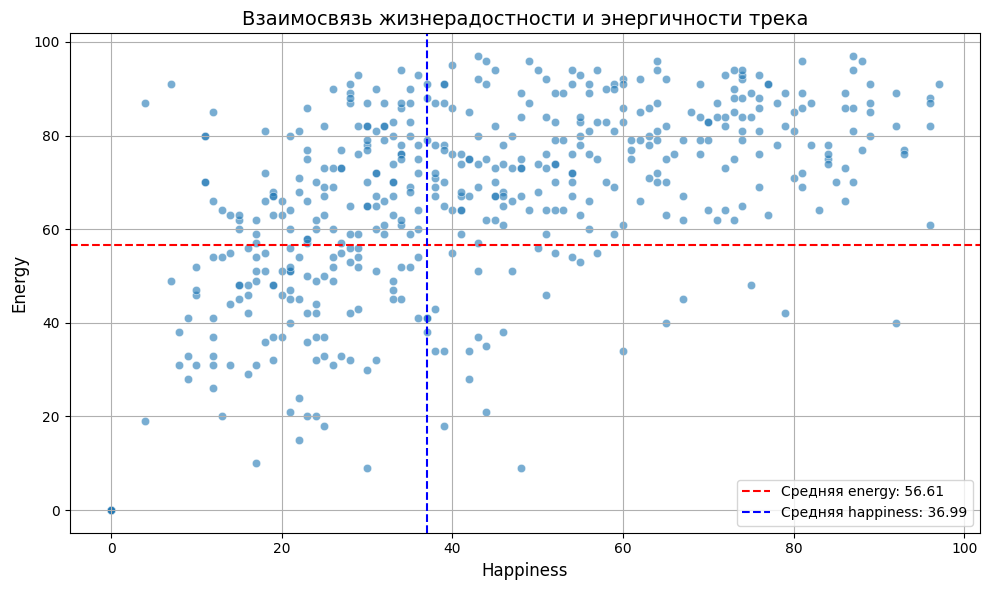

In [22]:
mean_happiness = df['happiness'].mean()
mean_energy = df['energy'].mean()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='happiness', y='energy', alpha=0.6, edgecolor='w', linewidth=0.5)

plt.axhline(mean_energy, color='red', linestyle='--', label=f'Средняя energy: {mean_energy:.2f}')
plt.axvline(mean_happiness, color='blue', linestyle='--', label=f'Средняя happiness: {mean_happiness:.2f}')

plt.title('Взаимосвязь жизнерадостности и энергичности трека', fontsize=14)
plt.xlabel('Happiness', fontsize=12)
plt.ylabel('Energy', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

import plotly.graph_objects as go
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df['happiness'],
    y=df['energy'],
    mode='markers',
    marker=dict(size=6, color='rgba(0, 123, 255, 0.6)', line=dict(width=0.5, color='white')),
    name='Композиции'
))

fig.add_trace(go.Scatter(
    x=[df['happiness'].min(), df['happiness'].max()],
    y=[mean_energy, mean_energy],
    mode='lines',
    line=dict(color='red', dash='dash'),
    name=f'Средняя energy: {mean_energy:.2f}'
))

fig.add_trace(go.Scatter(
    x=[mean_happiness, mean_happiness],
    y=[df['energy'].min(), df['energy'].max()],
    mode='lines',
    line=dict(color='blue', dash='dash'),
    name=f'Средняя happiness: {mean_happiness:.2f}'
))

fig.update_layout(
    title='Взаимосвязь жизнерадостности и энергичности трека (Plotly)',
    xaxis_title='Happiness',
    yaxis_title='Energy',
    width=1000,
    height=600,
    template='simple_white',
    legend=dict(x=0.01, y=0.99)
)

fig.show()

# Вывод
Можно заметить, достаточно сильно зависимы. Но самое интересное то, почти все радостные песни энергичные, неэнергичных прям очень мало. Это самое интересное, что можно было подметить, по моему мнению

## Задание 4

Покажите на горизонтальной столбчатой диаграмме распределение количества треков по жанрам. Отсортируйте диаграмму по убыванию количества композиций в жанре. Выделите контрастным цветом жанр, в котором больше всего песен.

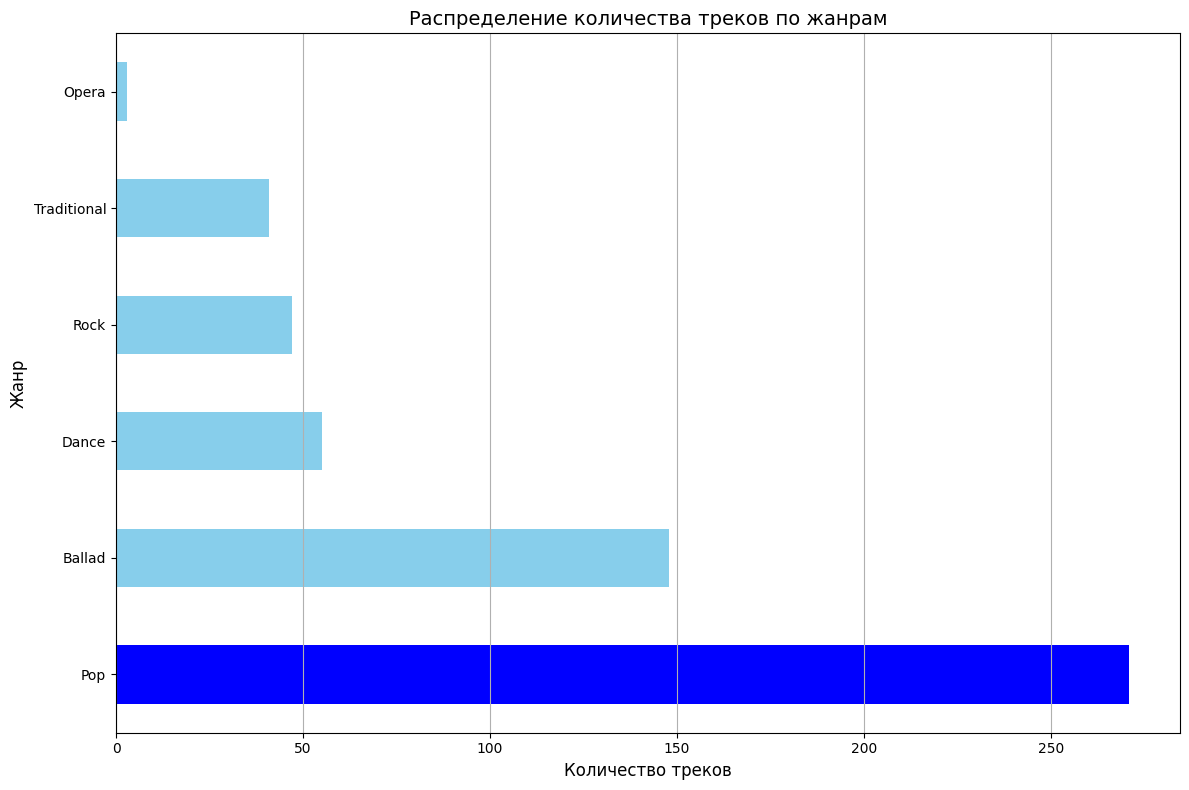

In [24]:
genre_counts = df['style'].value_counts()

colors = ['blue' if i == 5 else 'skyblue' for i in range(len(genre_counts))]

plt.figure(figsize=(12, 8))
genre_counts.plot(kind='barh', color=colors[::-1])

plt.title('Распределение количества треков по жанрам', fontsize=14)
plt.xlabel('Количество треков', fontsize=12)
plt.ylabel('Жанр', fontsize=12)
plt.grid(axis='x')
plt.tight_layout()
plt.show()


plotly_colors = ['royalblue' if i == 0 else 'lightblue' for i in range(len(genre_counts))]

fig = go.Figure(go.Bar(
    x=genre_counts.values[::-1],
    y=genre_counts.index[::-1],
    orientation='h',
    marker=dict(color=plotly_colors[::-1]),
    text=genre_counts.values[::-1],
    textposition='auto'
))

fig.update_layout(
    title='Распределение количества треков по жанрам (Plotly)',
    xaxis_title='Количество треков',
    yaxis_title='Жанр',
    width=1200,
    height=700,
    template='simple_white'
)

fig.show()

# Вывод
Как и ожидалось, поп-музыка преобладает, на втором месте баллады, хотя я ожидал там увидеть именно танцевальную, но ее оказлось в 2 с лишним раза меньше, чем баллад. Удивительнго, что на евровидении также присудствовали и оперные произведения, но их ничтожно мало.

## Задание 5

Покажите на круговой диаграмме страны, участники из которых побеждали чаще других, и в каких годах они выигрывали. Диаграмма должна быть одна.

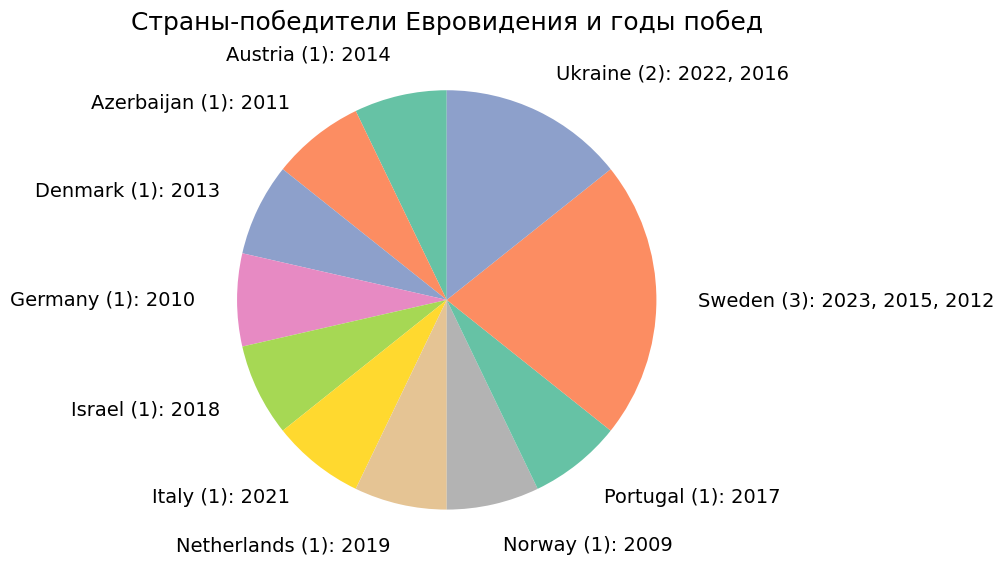

In [26]:
winners = df[df['final_place'] == 1]
country_wins = winners.groupby('country')['year'].agg(list)

labels = [
    f"{country} ({len(years)}): " + ", ".join(map(str, years))
    for country, years in country_wins.items()
]
sizes = [len(years) for years in country_wins.values]
colors = plt.cm.Set2.colors * ((len(labels) // len(plt.cm.Set2.colors)) + 1)
fig, ax = plt.subplots(figsize=(10, 10))

wedges, texts = ax.pie(
    sizes,
    startangle=90,
    colors=colors[:len(sizes)],
    labels=labels,
    labeldistance=1.2,
    textprops={'fontsize': 14}
)

ax.set_title("Страны-победители Евровидения и годы побед", fontsize=18)
plt.tight_layout()
plt.show()


plotly_df = pd.DataFrame({
    'country': country_wins.index,
    'years': country_wins.values,
    'count': [len(y) for y in country_wins.values]
})
plotly_df['label'] = plotly_df.apply(
    lambda row: f"{row['country']} ({row['count']}): " + ", ".join(map(str, row['years'])),
    axis=1
)

fig = px.pie(
    plotly_df,
    values='count',
    names='label',
    title='Страны-победители Евровидения и годы побед (Plotly)',
    color_discrete_sequence=px.colors.qualitative.Set2
)

fig.update_traces(textinfo='percent+label')
fig.update_layout(height=1000, width=1000)
fig.show()

# Вывод
Швеция чаще всего выигрывала, затем идет Украина, а потом уже все другие страны


## Задание 6

На вертикальной столбчатой диаграмме с группировкой покажите количество мужчин и женщин среди участников в каждом году, представленном в датасете.

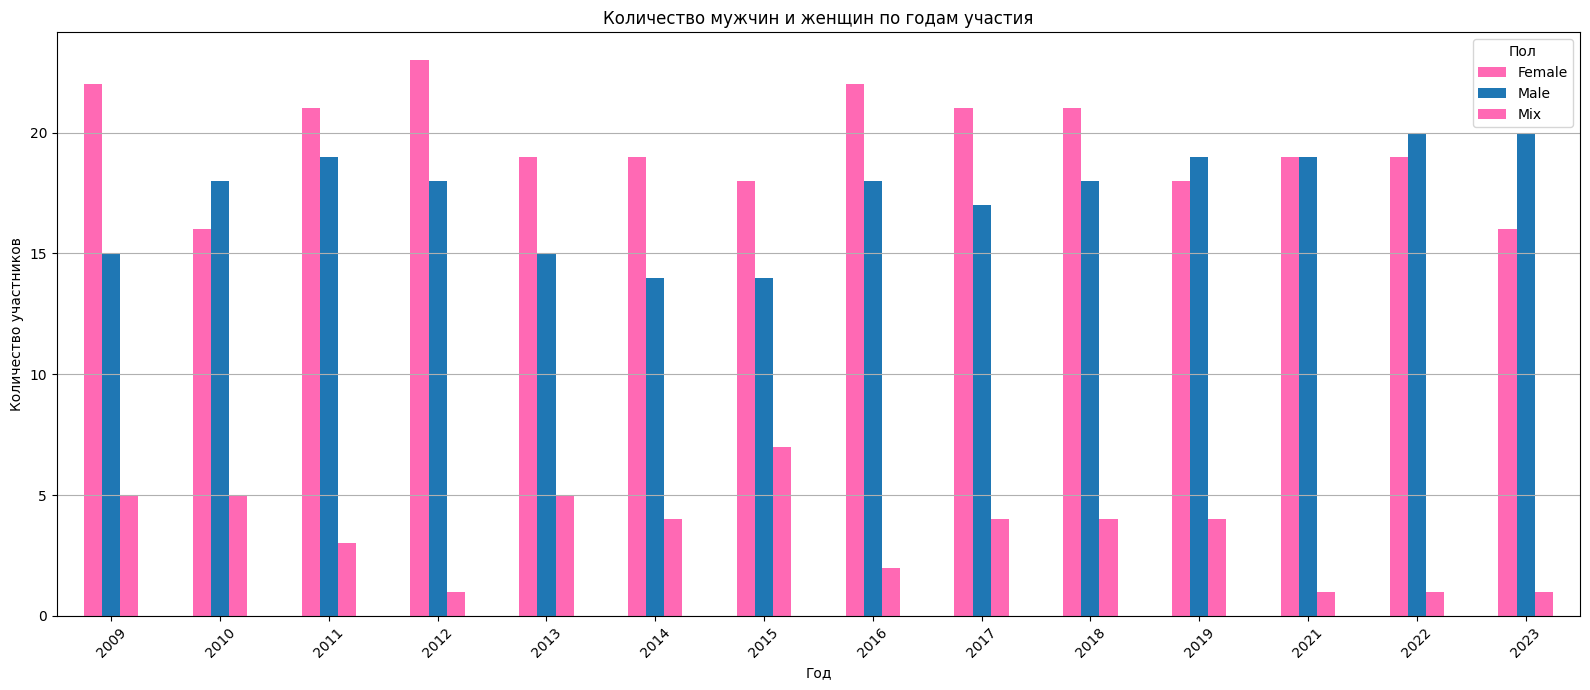

In [31]:
gender_counts = df.groupby(['year', 'gender']).size().unstack(fill_value=0)

gender_counts.plot(
    kind='bar',
    figsize=(16, 7),
    title='Количество мужчин и женщин по годам участия',
    color=['#ff69b4', '#1f77b4']
)

plt.xlabel('Год')
plt.ylabel('Количество участников')
plt.xticks(rotation=45)
plt.grid(True, axis='y')
plt.legend(title='Пол')
plt.tight_layout()
plt.show()



fig = go.Figure()

for gender in gender_counts.columns:
    fig.add_trace(go.Bar(
        x=gender_counts.index,
        y=gender_counts[gender],
        name=gender,
        marker_color='#ff69b4' if gender == 'Female' else '#1f77b4'
    ))

fig.update_layout(
    title='Количество мужчин и женщин по годам участия (Plotly)',
    xaxis_title='Год',
    yaxis_title='Количество участников',
    barmode='group',
    bargap=0.15,
    bargroupgap=0.05,
    width=1500,
    height=700,
    template='simple_white'
)

fig.show()

# Вывод
Оказвается в дф есть пол mix, вероятно это пары артистов или коллективы. Преимущественно артисты - женщины. Также интересно, что с 2019 года пошёл рост артистов мужчин

## Задание 7

Постройте график плотности распределения данных в столбце `danceability` (танцевальность), сгруппированных по категориям жанрам.

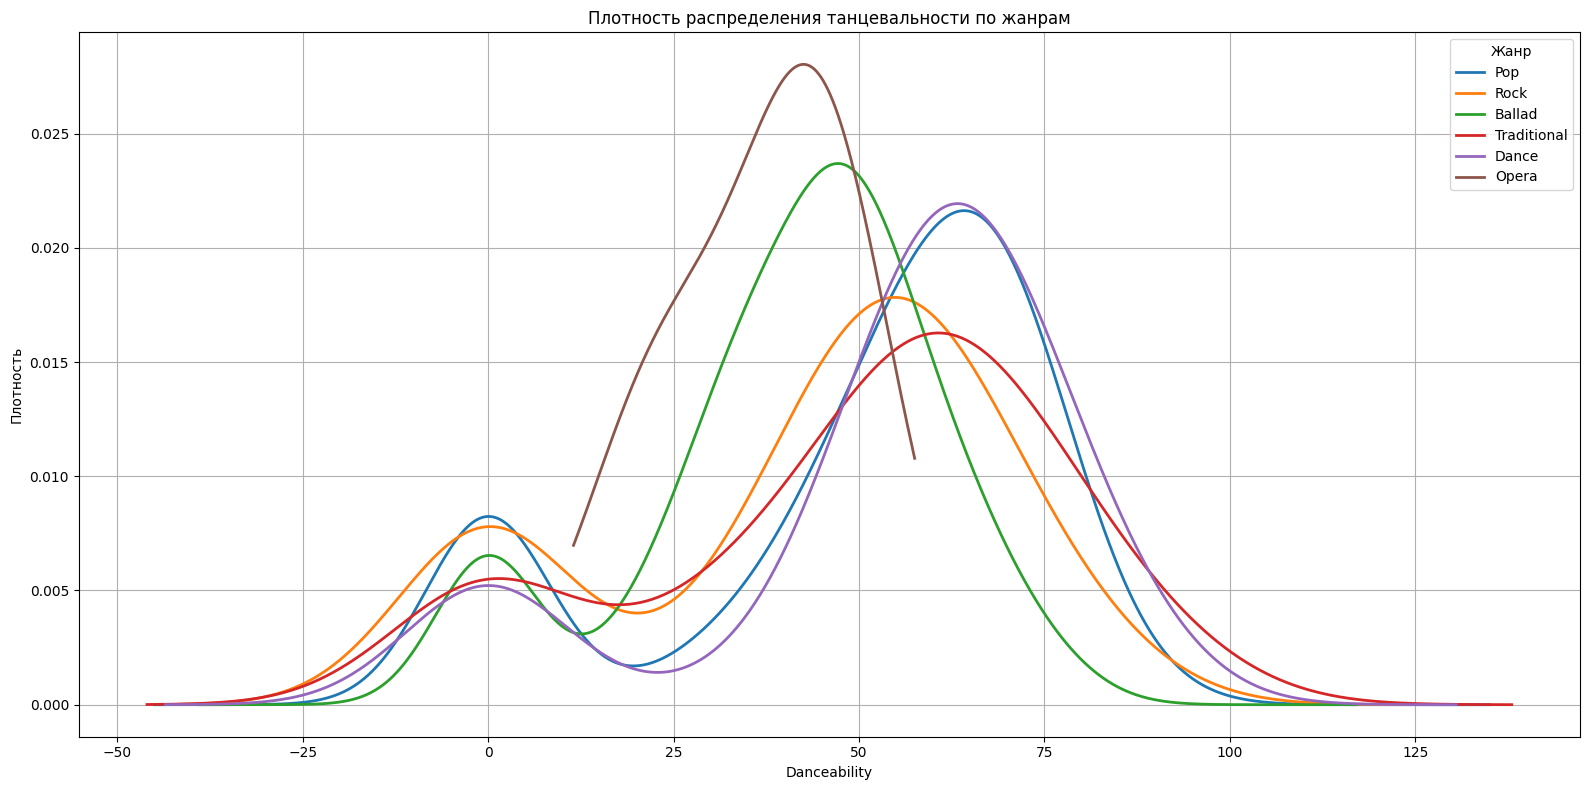

In [34]:
plt.figure(figsize=(16, 8))
for style_name in df['style'].dropna().unique():
    subset = df[df['style'] == style_name]
    subset['danceability'].plot(kind='kde', label=style_name, linewidth=2)

plt.title('Плотность распределения танцевальности по жанрам')
plt.xlabel('Danceability')
plt.ylabel('Плотность')
plt.legend(title='Жанр')
plt.grid(True)
plt.tight_layout()
plt.show()


from scipy.stats import gaussian_kde
fig = go.Figure()

styles = df['style'].dropna().unique()
x_vals = np.linspace(-50, 125, 500)

for style_name in styles:
    values = df[df['style'] == style_name]['danceability'].dropna()
    if len(values) > 1:
        kde = gaussian_kde(values)
        y_vals = kde(x_vals)
        fig.add_trace(go.Scatter(
            x=x_vals,
            y=y_vals,
            mode='lines',
            name=style_name
        ))

fig.update_layout(
    title='Плотность распределения танцевальности по жанрам (Plotly)',
    xaxis_title='Danceability',
    yaxis_title='Плотность',
    width=1500,
    height=600,
    template='simple_white'
)

fig.show()

# Вывод
Все значения примерно схожие, лишь опера слега отличается - её пик менее танцевальный чем пики других жанров. А так все жанры примерно одинаковы. Ну может еще баллады слегка отличаются


## Задание 8

Покажите на ящиковой диаграмме взяимосвязь позиции в финальном рейтинге со страной. Итоги каких стран похожи между собой?

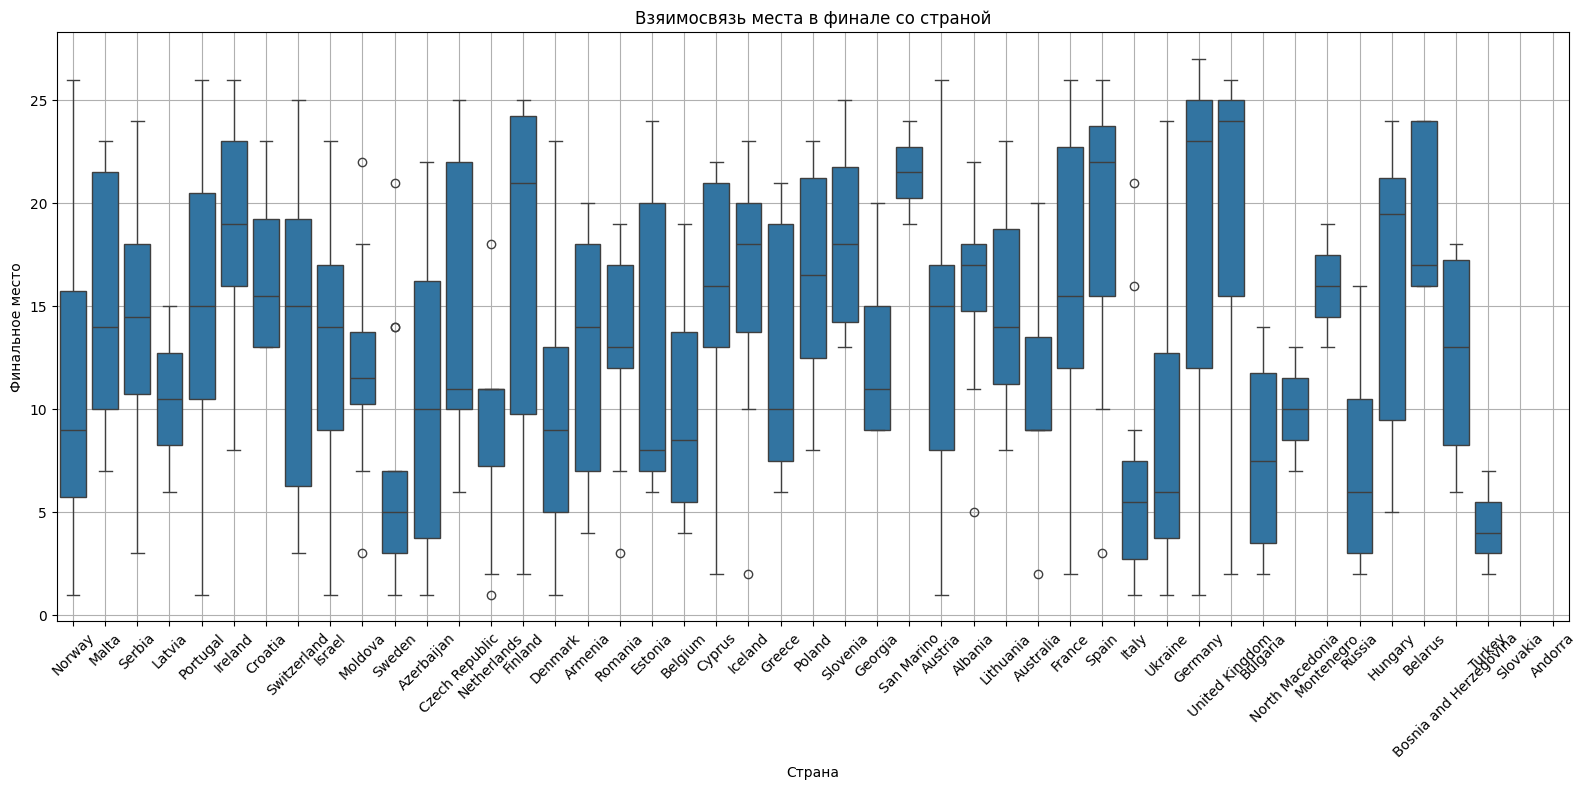

In [37]:
plt.figure(figsize=(16, 8))
sns.boxplot(data=df, x='country', y='final_place')
plt.title('Взяимосвязь места в финале со страной')
plt.xlabel('Страна')
plt.ylabel('Финальное место')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()



fig = px.box(df, x='country', y='final_place',
             title='Взаимосвязь места в финале со страной',
             labels={'country': 'Страна', 'final_place': 'Финальное место'},
             points='outliers')

fig.update_layout(
    xaxis_tickangle=45,
    width=1600,
    height=700,
    template='simple_white'
)

fig.show()

# Вывод
Швеция, Италия и Турция (особенно турция) стабильно хорошо выступают, но чемпионом по стабильности является Сан Марино со стабильно плохими результатами.


## Задание 9

Покажите на карте количество раз, когда каждая страна датасета проходила в финал.

<ipython-input-47-3bd0c0351e5c>:25: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




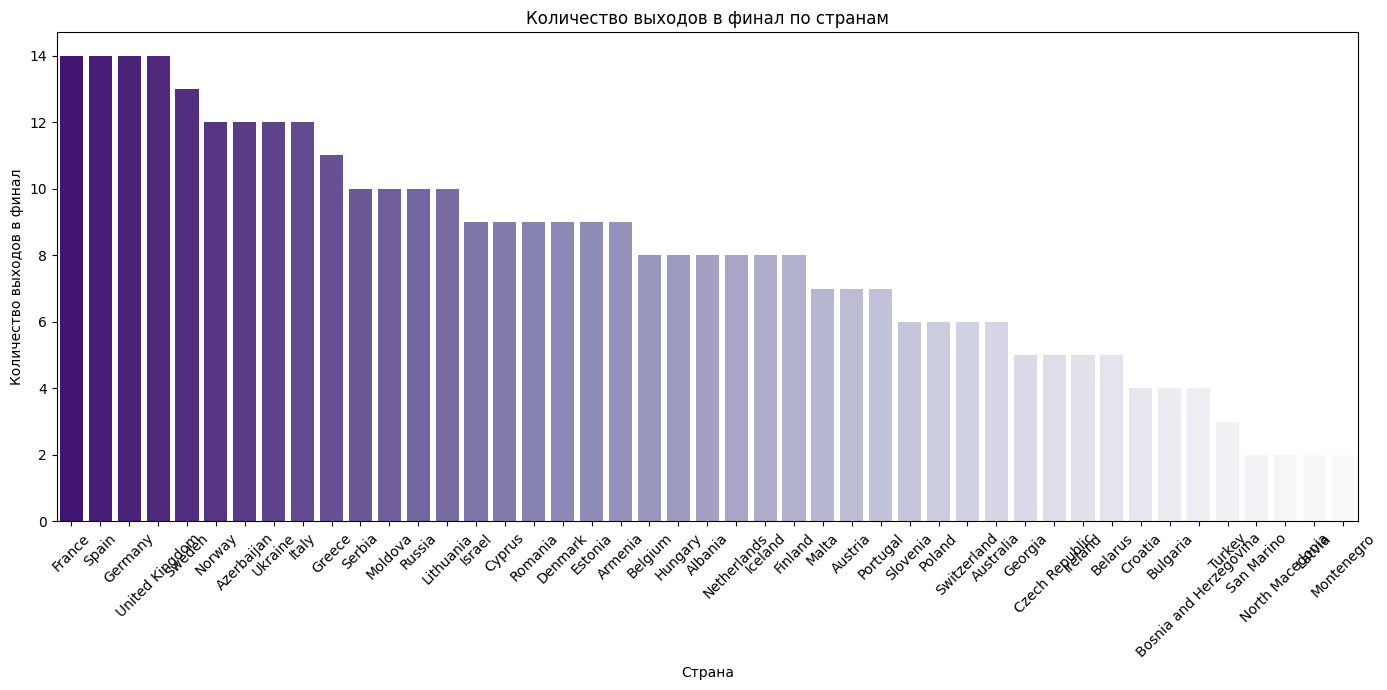

In [47]:
finals = df[df["final_place"].notna()]
final_counts = finals["country"].value_counts().reset_index()
final_counts.columns = ["country", "times_in_final"]

fig = px.choropleth(final_counts,
                    locations="country",
                    locationmode="country names",
                    color="times_in_final",
                    color_continuous_scale="purples",
                    title="Количество выходов в финал")

fig.update_geos(
    scope="europe",
    projection_type="natural earth",
    showcountries=True,
    landcolor="gray"
)

fig.update_layout(margin={"r":0,"t":50,"l":0,"b":0})
fig.show()



plt.figure(figsize=(14, 7))
sns.barplot(data=final_counts.sort_values('times_in_final', ascending=False),
            x='country', y='times_in_final', palette='Purples_r')
plt.title('Количество выходов в финал по странам')
plt.xlabel('Страна')
plt.ylabel('Количество выходов в финал')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Вывод
Франция, Испания, Германия, Великобритания - эти страны чаще всего выходили в финал

## Задание 10

Покажите на диаграмме вида `treemap`, сколько раз каждая страна входила в топ-3 победителей.

*В `seaborn` нет такого типа графика, с помощью этого модуля строить график не нужно.*

In [52]:
!pip install squarify

In [57]:
top3 = df[df["final_place"].isin([1, 2, 3])]

top3_counts = top3["country"].value_counts().reset_index()
top3_counts.columns = ["country", "top3_count"]

fig = px.treemap(top3_counts,
                 path=["country"],
                 values="top3_count",
                 color="top3_count",
                 color_continuous_scale="Reds",
                 title="Количество попаданий стран в топ-3 Евровидения")

fig.update_layout(margin={"r":0,"t":50,"l":0,"b":0})
fig.show()



import squarify

top3_counts_sorted = top3_counts.sort_values("top3_count", ascending=False)
sizes = top3_counts_sorted["top3_count"].tolist()
labels = top3_counts_sorted["country"].tolist()

rects = squarify.normalize_sizes(sizes, 100, 100)
rects = squarify.squarify(rects, 0, 0, 100, 100)

treemap_data = pd.DataFrame(rects)
treemap_data["country"] = labels
treemap_data["top3_count"] = sizes

treemap_data["x2"] = treemap_data["x"] + treemap_data["dx"]
treemap_data["y2"] = treemap_data["y"] + treemap_data["dy"]
treemap_data["x_center"] = treemap_data["x"] + treemap_data["dx"] / 2
treemap_data["y_center"] = treemap_data["y"] + treemap_data["dy"] / 2

treemap_rects = alt.Chart(treemap_data).mark_rect().encode(
    x=alt.X('x:Q', scale=alt.Scale(domain=[0, 100]), axis=None),
    x2='x2:Q',
    y=alt.Y('y:Q', scale=alt.Scale(domain=[0, 100]), axis=None),
    y2='y2:Q',
    color=alt.Color('top3_count:Q', scale=alt.Scale(scheme='reds')),
    tooltip=['country:N', 'top3_count:Q']
)

treemap_labels = alt.Chart(treemap_data).mark_text(
    align='center',
    baseline='middle',
    fontSize=14,
    fontWeight='bold',
    color='black'
).encode(
    x='x_center:Q',
    y='y_center:Q',
    text='country:N'
)

alt_chart = (treemap_rects + treemap_labels).properties(
    width=1500,
    height=700,
    title='Количество попаданий стран в топ-3 Евровидения (Altair)'
)

alt_chart

alt.LayerChart(...)

# Вывод
Швеция лидирует, а за ней Россия и Италия. Все белые страны попадали в топ 3 всего по 1 разу

# Доп задание
Постройте диаграмму "скрипка", показывающую распределение happiness (жизнерадостности) по жанрам. Выполните с помощью seaborn.

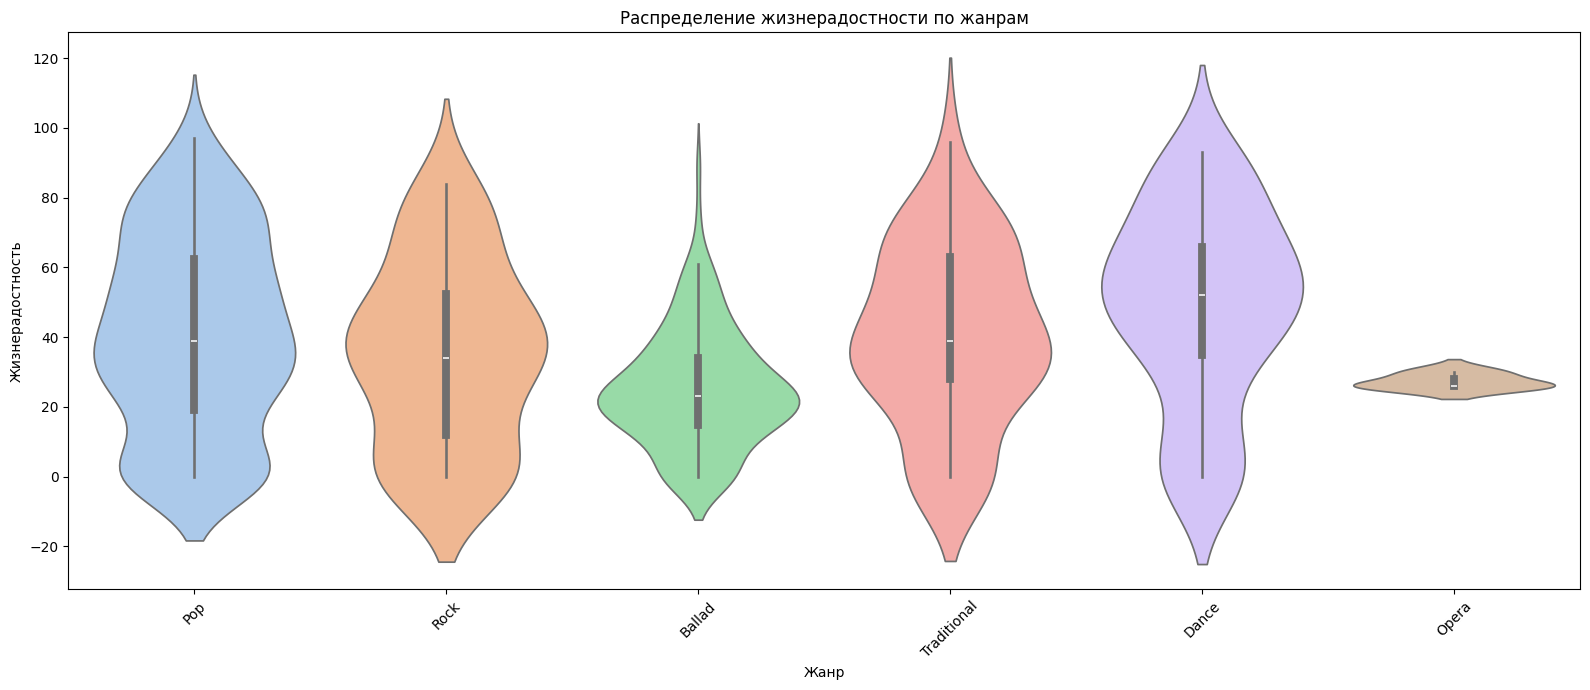

In [14]:
df = df.dropna(subset=["happiness", "style"])

plt.figure(figsize=(16, 7))

sns.violinplot(data=df, x="style", y="happiness", hue="style", palette="pastel")
plt.title("Распределение жизнерадостности по жанрам")
plt.xlabel("Жанр")
plt.ylabel("Жизнерадостность")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Порядок защиты работы

**Для защиты работы необходимо:**
1. Предоставить результаты выполнения 10 заданий в виде ссылки на Google Colab.
2. Выполнить дополнительное задание в процессе сдачи работы. Дополнительное задание представляет собой построение визуализации по данным из лабораторной работы, по сложности аналогичной тем, что требовалось выполнить в рамках работы.

**Примеры дополнительных заданий:**
1. Покажите на ящиковой диаграмме распределение танцевальности для каждого жанра. Выполните с помощью `seaborn`.
2. На круговой диаграмме покажите исполнителей, которые участвовали больше одного раза и какие места они занимали. Выполните с помощью `plotly`.
3. Покажите на диаграмме вида `treemap`, сколько раз каждая страна проходила в финал. Выполните с помощью `plotly`.

# Дополнительные материалы

1. seaborn: statistical data visualization [Электронный ресурс]. URL: https://seaborn.pydata.org/ (дата обращения: 01.04.2024).
2. Plotly Open Source Graphing Libraries [Электронный ресурс]. URL: https://plotly.com/graphing-libraries/ (дата обращения: 01.04.2024).
3. Vega-Altair: Declarative Visualization in Python [Электронный ресурс]. URL: https://altair-viz.github.io/index.html (дата обращения: 01.04.2024).